In [28]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

drive_path = "/content/drive/MyDrive/PROJECT_FSD50K"
local_path = "/content/fsd50k_local"

# Only extract the audio archives if they haven't been extracted already
dev_audio_dir = os.path.join(local_path, "FSD50K.dev_audio")

if os.path.exists(dev_audio_dir) and len(os.listdir(dev_audio_dir)) > 100:
    print(f"Dataset already extracted at {local_path}")
else:
    print("Extracting dataset archives")
    !unzip -q {drive_path}/FSD50K.metadata.zip -d {local_path}
    !unzip -q {drive_path}/FSD50K.ground_truth.zip -d {local_path}
    !7z x {drive_path}/FSD50K.eval_audio.zip -o{local_path} -y > /dev/null
    !7z x {drive_path}/FSD50K.dev_audio.zip -o{local_path} -y > /dev/null
    print("Extraction complete.")

Mounted at /content/drive
Dataset already extracted at /content/fsd50k_local


# **Label Redundancy Analysis**

## **Purpose**

This notebook performs a systematic co-occurrence analysis on the FSD50K label space to identify and remove redundant labels from the classification vocabulary. The motivation is methodological: during the baseline presentation the professor pointed out that two label pairs (`Music`/`Musical_instrument`, `Guitar`/`Plucked_string_instrument`) were strongly correlated and could inflate macro-averaged metrics. Rather than restricting the elimination to those two hand-picked pairs, we apply the same underlying criterion to every label pair, turning a qualitative observation into a reproducible data-driven rule.

The output is the definitive `DROP_LABELS` set used by notebooks `04_cnn`, `05_ast`, and `06_robustness`.

In [29]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

BASE_DIR = "/content/fsd50k_local"
DEV_CSV  = os.path.join(BASE_DIR, "FSD50K.ground_truth", "dev.csv")

dev_df = pd.read_csv(DEV_CSV)
dev_df["label_list"] = dev_df["labels"].astype(str).str.split(",")

print(f"Total dev samples: {len(dev_df)}")
print(f"Example labels: {dev_df['label_list'].iloc[0]}")

Total dev samples: 40966
Example labels: ['Electric_guitar', 'Guitar', 'Plucked_string_instrument', 'Musical_instrument', 'Music']


In [30]:
# Count the frequency of each label across the dev set
all_labels   = [l for ls in dev_df["label_list"] for l in ls]
label_counts = pd.Series(all_labels).value_counts()

print(f"Total unique labels: {len(label_counts)}")
print(f"Total label assignments: {len(all_labels)}")

# Keep only labels with enough samples to produce reliable co-occurrence stats
MIN_SUPPORT = 30
candidate_labels = label_counts[label_counts >= MIN_SUPPORT].index.tolist()

print(f"\nLabels kept (support >= {MIN_SUPPORT}): {len(candidate_labels)}")

Total unique labels: 200
Total label assignments: 114271

Labels kept (support >= 30): 200


## **Support Filtering**

Before computing co-occurrence statistics we restrict the analysis to labels that appear at least 30 times in the development set. Labels with very few samples produce noisy co-occurrence percentages: if a label appears only 5 times and always co-occurs with another, the 100% rate is not evidence of redundancy but of insufficient data. This filter keeps all 200 official classes of FSD50K.

In [31]:
# Count frequency of each label
all_labels   = [l for ls in dev_df["label_list"] for l in ls]
label_counts = pd.Series(all_labels).value_counts()

print(f"Total unique labels: {len(label_counts)}")
print(f"Total label assignments: {len(all_labels)}")

# Keep only labels with enough samples for reliable co-occurrence statistics
MIN_SUPPORT = 30
candidate_labels = label_counts[label_counts >= MIN_SUPPORT].index.tolist()
print(f"Labels kept (support >= {MIN_SUPPORT}): {len(candidate_labels)}")

Total unique labels: 200
Total label assignments: 114271
Labels kept (support >= 30): 200


## **Directional Co-occurrence Computation**

For every unordered pair of labels `(A, B)` we compute two conditional probabilities:

- **P(B | A)**: among samples containing A, what fraction also contain B.
- **P(A | B)**: the reverse direction.

These two values are **not symmetric** and their joint inspection reveals the type of relationship:

- Both probabilities high → near-synonyms (**redundant**).
- Only one high, the other low → one label is a subset of the other (legitimate hierarchy).
- Neither high → weakly linked.

Each pair is classified into one of five categories: `REDUNDANT`, `A subset of B`, `B subset of A`, `STRONGLY LINKED` (gray zone), or `weakly linked`.

In [32]:
# Pre-compute per-sample label sets and per-label support for faster lookups
label_sets = dev_df["label_list"].apply(set).tolist()
supports   = {lab: sum(1 for s in label_sets if lab in s) for lab in candidate_labels}

results = []
for a, b in combinations(candidate_labels, 2):
    n_a, n_b = supports[a], supports[b]
    n_both   = sum(1 for s in label_sets if a in s and b in s)

    if n_a == 0 or n_b == 0:
        continue

    p_b_given_a = 100 * n_both / n_a
    p_a_given_b = 100 * n_both / n_b

    # Classify the relationship
    if p_b_given_a >= 90 and p_a_given_b >= 90:
        relation = "REDUNDANT"
    elif p_b_given_a >= 90 and p_a_given_b < 70:
        relation = "A subset of B"
    elif p_a_given_b >= 90 and p_b_given_a < 70:
        relation = "B subset of A"
    elif max(p_b_given_a, p_a_given_b) >= 80:
        relation = "STRONGLY LINKED"
    else:
        relation = "weakly linked"

    results.append({
        "label_A":     a,
        "label_B":     b,
        "support_A":   n_a,
        "support_B":   n_b,
        "both":        n_both,
        "P(B|A)_%":    round(p_b_given_a, 1),
        "P(A|B)_%":    round(p_a_given_b, 1),
        "max_cooc_%":  round(max(p_b_given_a, p_a_given_b), 1),
        "relation":    relation,
    })

pairs_df = pd.DataFrame(results)
print(f"Total pairs analyzed: {len(pairs_df)}")

Total pairs analyzed: 19900


## **Distribution Overview**

This section summarizes how the detected pairs distribute across relationship types and co-occurrence ranges. The key empirical finding is the **bimodal distribution** of maximum co-occurrence values: pairs cluster either below 70% (weakly linked or moderate) or above 95% (near-synonyms or pure hierarchies), with a complete gap in the 70–95% range. This absence of intermediate cases makes any threshold in that region equivalent in practice and provides objective justification for adopting a 95% threshold to define redundancy.

=== Distribution of pair relationships ===

relation
weakly linked      19604
B subset of A        289
REDUNDANT              5
STRONGLY LINKED        2

=== Distribution of max co-occurrence across bins ===

max_cooc_%
(0, 50]      2543
(50, 70]       14
(70, 80]        0
(80, 85]        0
(85, 90]        0
(90, 95]        0
(95, 100]     296


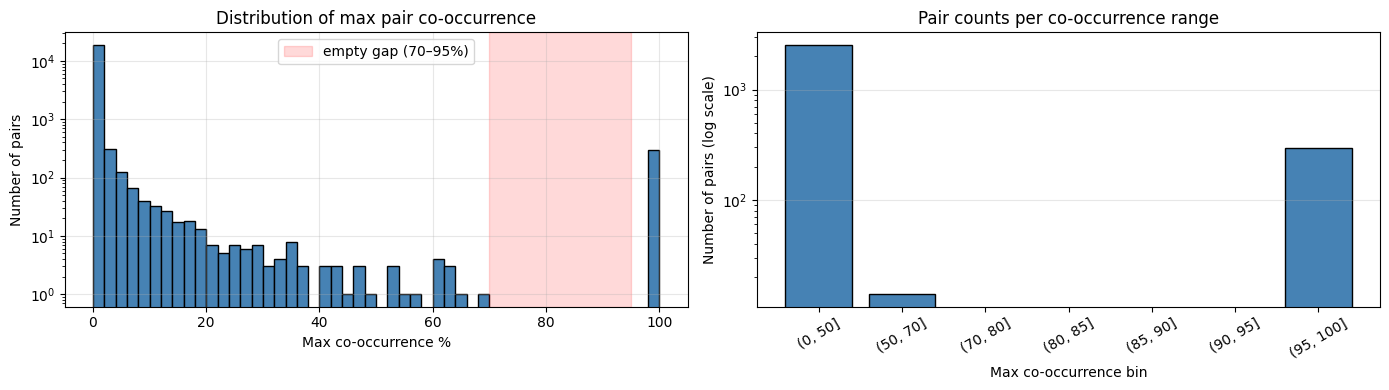

In [33]:
# Relationship type distribution
print("=== Distribution of pair relationships ===\n")
print(pairs_df["relation"].value_counts().to_string())

# Max co-occurrence distribution in bins
print("\n=== Distribution of max co-occurrence across bins ===\n")
bins   = [0, 50, 70, 80, 85, 90, 95, 100]
binned = pd.cut(pairs_df["max_cooc_%"], bins=bins)
print(binned.value_counts().sort_index().to_string())

# Visualization of the bimodal distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of max co-occurrence
ax[0].hist(pairs_df["max_cooc_%"], bins=np.arange(0, 101, 2), color="steelblue", edgecolor="black")
ax[0].axvspan(70, 95, alpha=0.15, color="red", label="empty gap (70–95%)")
ax[0].set_xlabel("Max co-occurrence %")
ax[0].set_ylabel("Number of pairs")
ax[0].set_yscale("log")
ax[0].set_title("Distribution of max pair co-occurrence")
ax[0].legend()
ax[0].grid(alpha=.3)

# Right: barplot of the discrete bins
bin_counts = binned.value_counts().sort_index()
bin_labels = [str(b) for b in bin_counts.index]
colors = ["steelblue"] * len(bin_counts)
# Highlight the empty gap
for i, b in enumerate(bin_counts.index):
    if b.left >= 70 and b.right <= 95:
        colors[i] = "lightcoral"
ax[1].bar(bin_labels, bin_counts.values, color=colors, edgecolor="black")
ax[1].set_xlabel("Max co-occurrence bin")
ax[1].set_ylabel("Number of pairs (log scale)")
ax[1].set_yscale("log")
ax[1].set_title("Pair counts per co-occurrence range")
ax[1].tick_params(axis="x", rotation=30)
ax[1].grid(alpha=.3, axis="y")

plt.tight_layout()
plt.show()

## **Redundant Pairs**

Pairs where **both** directional probabilities exceed 90% are candidates for elimination.

In [34]:
redundant = pairs_df[pairs_df["relation"] == "REDUNDANT"]\
            .sort_values("max_cooc_%", ascending=False).reset_index(drop=True)

print(f"=== REDUNDANT pairs (n={len(redundant)}) — candidates for elimination ===\n")
print(redundant.to_string(index=False))

=== REDUNDANT pairs (n=5) — candidates for elimination ===

                  label_A             label_B  support_A  support_B  both  P(B|A)_%  P(A|B)_%  max_cooc_%  relation
                    Music  Musical_instrument      12767      12763 12763     100.0     100.0       100.0 REDUNDANT
Plucked_string_instrument              Guitar       1916       1821  1821      95.0     100.0       100.0 REDUNDANT
             Thunderstorm             Thunder        469        455   455      97.0     100.0       100.0 REDUNDANT
               Power_tool               Drill        171        169   169      98.8     100.0       100.0 REDUNDANT
                     Pour Trickle_and_dribble        154        150   150      97.4     100.0       100.0 REDUNDANT


## **Legitimate Hierarchies**

Pairs where one direction is near 100% but the other stays well below 70% reflect parent-child relationships: every `Thunder` sample is also a `Thunderstorm`, but not vice versa. These pairs must be preserved, eliminating either label would erase information. They are also the relationships most directly relevant to the project's hypothesis, that AST's global attention should disambiguate parent from child better than the CNN's local features.

In [35]:
hierarchies = pairs_df[pairs_df["relation"].str.contains("subset", na=False)]\
              .sort_values("max_cooc_%", ascending=False).reset_index(drop=True)

print(f"=== LEGITIMATE HIERARCHIES (n={len(hierarchies)}) — keep both labels ===\n")
print(hierarchies.head(25).to_string(index=False))
if len(hierarchies) > 25:
    print(f"\n... and {len(hierarchies) - 25} more")

=== LEGITIMATE HIERARCHIES (n=289) — keep both labels ===

                                       label_A                               label_B  support_A  support_B  both  P(B|A)_%  P(A|B)_%  max_cooc_%      relation
                                         Chime                            Wind_chime        166         66    66      39.8     100.0       100.0 B subset of A
                                          Rain                              Raindrop        500        119   119      23.8     100.0       100.0 B subset of A
 Bird_vocalization_and_bird_call_and_bird_song                       Chirp_and_tweet        502        194   194      38.6     100.0       100.0 B subset of A
Livestock_and_farm_animals_and_working_animals                   Chicken_and_rooster        515        138   138      26.8     100.0       100.0 B subset of A
Livestock_and_farm_animals_and_working_animals                                  Fowl        515        224   224      43.5     100.0       100.0 B

## **Intersection of Redundant Pairs with the Top-100 Vocabulary**

Not every redundant pair affects the downstream models. The final classification task uses only the 100 most frequent labels. A redundant pair involving rare labels (for example `Power_tool`/`Drill` with ~170 samples each) does not affect training and can be ignored. This section checks which labels from the redundant pairs actually appear in the Top-100, narrowing the elimination set.

In [36]:
top100 = set([l for l, _ in label_counts.items()][:100])

# For each redundant pair, identify labels that are actually in the Top-100
print(f"{'Label':<30s} {'in Top-100?':<12s} {'support'}")
print("-" * 55)
for _, row in redundant.iterrows():
    for lab in [row["label_A"], row["label_B"]]:
        in_top = "YES" if lab in top100 else "no"
        supp   = label_counts.get(lab, 0)
        print(f"{lab:<30s} {in_top:<12s} {supp}")
    print("-" * 55)

Label                          in Top-100?  support
-------------------------------------------------------
Music                          YES          12767
Musical_instrument             YES          12763
-------------------------------------------------------
Plucked_string_instrument      YES          1916
Guitar                         YES          1821
-------------------------------------------------------
Thunderstorm                   YES          469
Thunder                        YES          455
-------------------------------------------------------
Power_tool                     no           171
Drill                          no           169
-------------------------------------------------------
Pour                           no           154
Trickle_and_dribble            no           150
-------------------------------------------------------


## **Final Vocabulary Construction**

The definitive `DROP_LABELS` set contains three labels: `Musical_instrument`, `Plucked_string_instrument`, and `Thunderstorm`. In each pair the more generic (parent) label is dropped and the more specific (child) is retained, preserving acoustic specificity.

A subtle design decision concerns the order of operations. Two approaches are possible:

- **Drop first, then Top-100**: yields exactly 100 classes and brings in three additional labels with ≥220 samples each (`Bass_drum`, `Fowl`, `Bus`).
- **Top-100 first, then drop**: yields 97 classes.

We adopt the first approach: it produces a round vocabulary size and provides slightly broader coverage at no additional training cost.

In [37]:
DROP_LABELS = {
    "Musical_instrument",         # 100% co-occurrence with Music
    "Plucked_string_instrument",  #  95% co-occurrence with Guitar
    "Thunderstorm",               #  97% co-occurrence with Thunder
}

# Drop first, then take the Top-100 by frequency
top_labels = [l for l, _ in label_counts.items() if l not in DROP_LABELS][:100]

# Comparison with the alternative approach (Top-100 first, then drop)
top100_first_then_drop = [l for l, _ in label_counts.items()][:100]
top100_first_then_drop = [l for l in top100_first_then_drop if l not in DROP_LABELS]

new_entries = set(top_labels) - set(top100_first_then_drop)

print(f"Drop first → then Top-100:   {len(top_labels)} classes")
print(f"Top-100 first → then drop:   {len(top100_first_then_drop)} classes")
print(f"\nAdditional labels gained by filtering first:")
for lab in sorted(new_entries):
    print(f"  {lab:<20s} support = {label_counts[lab]}")

Drop first → then Top-100:   100 classes
Top-100 first → then drop:   97 classes

Additional labels gained by filtering first:
  Bass_drum            support = 220
  Bus                  support = 223
  Fowl                 support = 224


## **Vocabulary Internal Check**

Exhaustive pair-wise check inside the final 100-class vocabulary to confirm that no redundant pair remains after filtering, closing the methodological loop.

In [38]:
# Re-use supports; recompute the subset corresponding to the final vocabulary
vocab_supports = {l: supports[l] for l in top_labels if l in supports}

vocab_rows = []
for a, b in combinations(top_labels, 2):
    if a not in supports or b not in supports:
        continue
    n_a, n_b = supports[a], supports[b]
    n_both   = sum(1 for s in label_sets if a in s and b in s)

    p_b_given_a = 100 * n_both / n_a
    p_a_given_b = 100 * n_both / n_b
    max_cooc    = max(p_b_given_a, p_a_given_b)

    if p_b_given_a >= 90 and p_a_given_b >= 90:
        relation = "REDUNDANT"
    elif p_b_given_a >= 90 and p_a_given_b < 70:
        relation = "A subset of B"
    elif p_a_given_b >= 90 and p_b_given_a < 70:
        relation = "B subset of A"
    elif max_cooc >= 80:
        relation = "STRONGLY LINKED"
    else:
        relation = "weakly linked"

    vocab_rows.append({
        "label_A": a, "label_B": b,
        "P(B|A)_%": round(p_b_given_a, 1),
        "P(A|B)_%": round(p_a_given_b, 1),
        "max_cooc_%": round(max_cooc, 1),
        "relation": relation,
    })

vocab_pairs_df = pd.DataFrame(vocab_rows)

print("=== Relationship distribution within the final 100-class vocabulary ===\n")
print(vocab_pairs_df["relation"].value_counts().to_string())

print("\n=== REDUNDANT pairs inside the final vocabulary ===\n")
vocab_redundant = vocab_pairs_df[vocab_pairs_df["relation"] == "REDUNDANT"]
if len(vocab_redundant) == 0:
    print("(none — final vocabulary is free of redundancy)")
else:
    print(vocab_redundant.to_string(index=False))

print("\n=== STRONGLY LINKED pairs (gray zone) inside the final vocabulary ===\n")
vocab_gray = vocab_pairs_df[vocab_pairs_df["relation"] == "STRONGLY LINKED"]\
             .sort_values("max_cooc_%", ascending=False)
if len(vocab_gray) == 0:
    print("(none)")
else:
    print(vocab_gray.to_string(index=False))

=== Relationship distribution within the final 100-class vocabulary ===

relation
weakly linked      4844
B subset of A       104
STRONGLY LINKED       2

=== REDUNDANT pairs inside the final vocabulary ===

(none — final vocabulary is free of redundancy)

=== STRONGLY LINKED pairs (gray zone) inside the final vocabulary ===

                  label_A label_B  P(B|A)_%  P(A|B)_%  max_cooc_%        relation
             Wild_animals    Bird      72.5     100.0       100.0 STRONGLY LINKED
Domestic_animals_and_pets     Dog      71.3     100.0       100.0 STRONGLY LINKED


## **Save Configuration**

The vocabulary configuration is written to Drive as a JSON file. Notebooks `04_cnn`, `05_ast`, and `06_robustness` load this file at startup, guaranteeing that every trained model shares the same label space.

In [39]:
config = {
    "drop_labels":               sorted(list(DROP_LABELS)),
    "vocabulary_size":           100,
    "selection_rule":            "top-N by frequency AFTER dropping redundant labels",
    "co_occurrence_threshold_%": 95,
}

out_path = "/content/drive/MyDrive/PROJECT_FSD50K/label_config.json"
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved to: {out_path}\n")
print(json.dumps(config, indent=2))

Saved to: /content/drive/MyDrive/PROJECT_FSD50K/label_config.json

{
  "drop_labels": [
    "Musical_instrument",
    "Plucked_string_instrument",
    "Thunderstorm"
  ],
  "vocabulary_size": 100,
  "selection_rule": "top-N by frequency AFTER dropping redundant labels",
  "co_occurrence_threshold_%": 95
}


## **Conclusion**

- **5 redundant pairs detected** in the full dataset of 200 classes, 3 of them affecting the Top-100 (`Music`/`Musical_instrument`, `Guitar`/`Plucked_string_instrument`, `Thunder`/`Thunderstorm`). The more generic label of each pair is dropped.
- **289 legitimate hierarchies** identified (asymmetric subset relations). These are preserved, as they carry real semantic information.
- **Bimodal distribution**: no pair has a maximum co-occurrence between 70% and 95%, which provides objective justification for the 95% threshold.
- **Internal validation of the final vocabulary**: 0 redundant pairs remain inside the 100 selected classes, confirming that no metric-inflating pair has been overlooked.
- **Final vocabulary**: 100 classes, minimum support of 220 samples per class, stored in `label_config.json` for downstream use.